# **Machine Learning Homework** - Combining Evolutionary Learning, Active Learning and Ensemble Learning to solve the Higgs Bozon Detection
MARCELINO Auriane

## Sommaire
- [I - Preprocessing](#i---dataset-preprocessing)
    - [1. Import](#1-import-csv-file)
    - [2. Delete columns](#2-delete-superfluous-columns)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn import model_selection
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

## I - Dataset preprocessing

### 1. Import CSV file

In [2]:
atlas = pd.read_csv('atlas-higgs.csv')
# I create a copy of the data to work on it, and I keep the original one safe to avoid re-importing it if there is a problem
data = atlas.copy()
print(data.shape)
print(data.dtypes)
data.head()

(818238, 35)
EventId                          int64
DER_mass_MMC                   float64
DER_mass_transverse_met_lep    float64
DER_mass_vis                   float64
DER_pt_h                       float64
DER_deltaeta_jet_jet           float64
DER_mass_jet_jet               float64
DER_prodeta_jet_jet            float64
DER_deltar_tau_lep             float64
DER_pt_tot                     float64
DER_sum_pt                     float64
DER_pt_ratio_lep_tau           float64
DER_met_phi_centrality         float64
DER_lep_eta_centrality         float64
PRI_tau_pt                     float64
PRI_tau_eta                    float64
PRI_tau_phi                    float64
PRI_lep_pt                     float64
PRI_lep_eta                    float64
PRI_lep_phi                    float64
PRI_met                        float64
PRI_met_phi                    float64
PRI_met_sumet                  float64
PRI_jet_num                      int64
PRI_jet_leading_pt             float64
PRI_jet_lead

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label,KaggleSet,KaggleWeight
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2.150,0.444,46.062,1.24,-2.475,113.497,0.000814,s,t,0.002653
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,0.725,1.158,-999.000,-999.00,-999.000,46.226,0.681042,b,t,2.233584
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,2.053,-2.028,-999.000,-999.00,-999.000,44.251,0.715742,b,t,2.347389
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,1.660654,b,t,5.446378
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,1.904263,b,t,6.245333


### 2. Delete superfluous columns

We delete some columns that are not usefull

In [3]:
del(data['EventId'])
del(data['Weight'])
del(data['KaggleSet'])
del(data['KaggleWeight'])

### 3. Transform label

We simplify the *Label* column, the value by 1 if it's a 's' (for 'signal'), and 0 if it's a 'b' (for 'background')

In [4]:
data['Label'] = data['Label'].apply(lambda x: 1 if x == 's' else 0)

### 4. Check data repartition

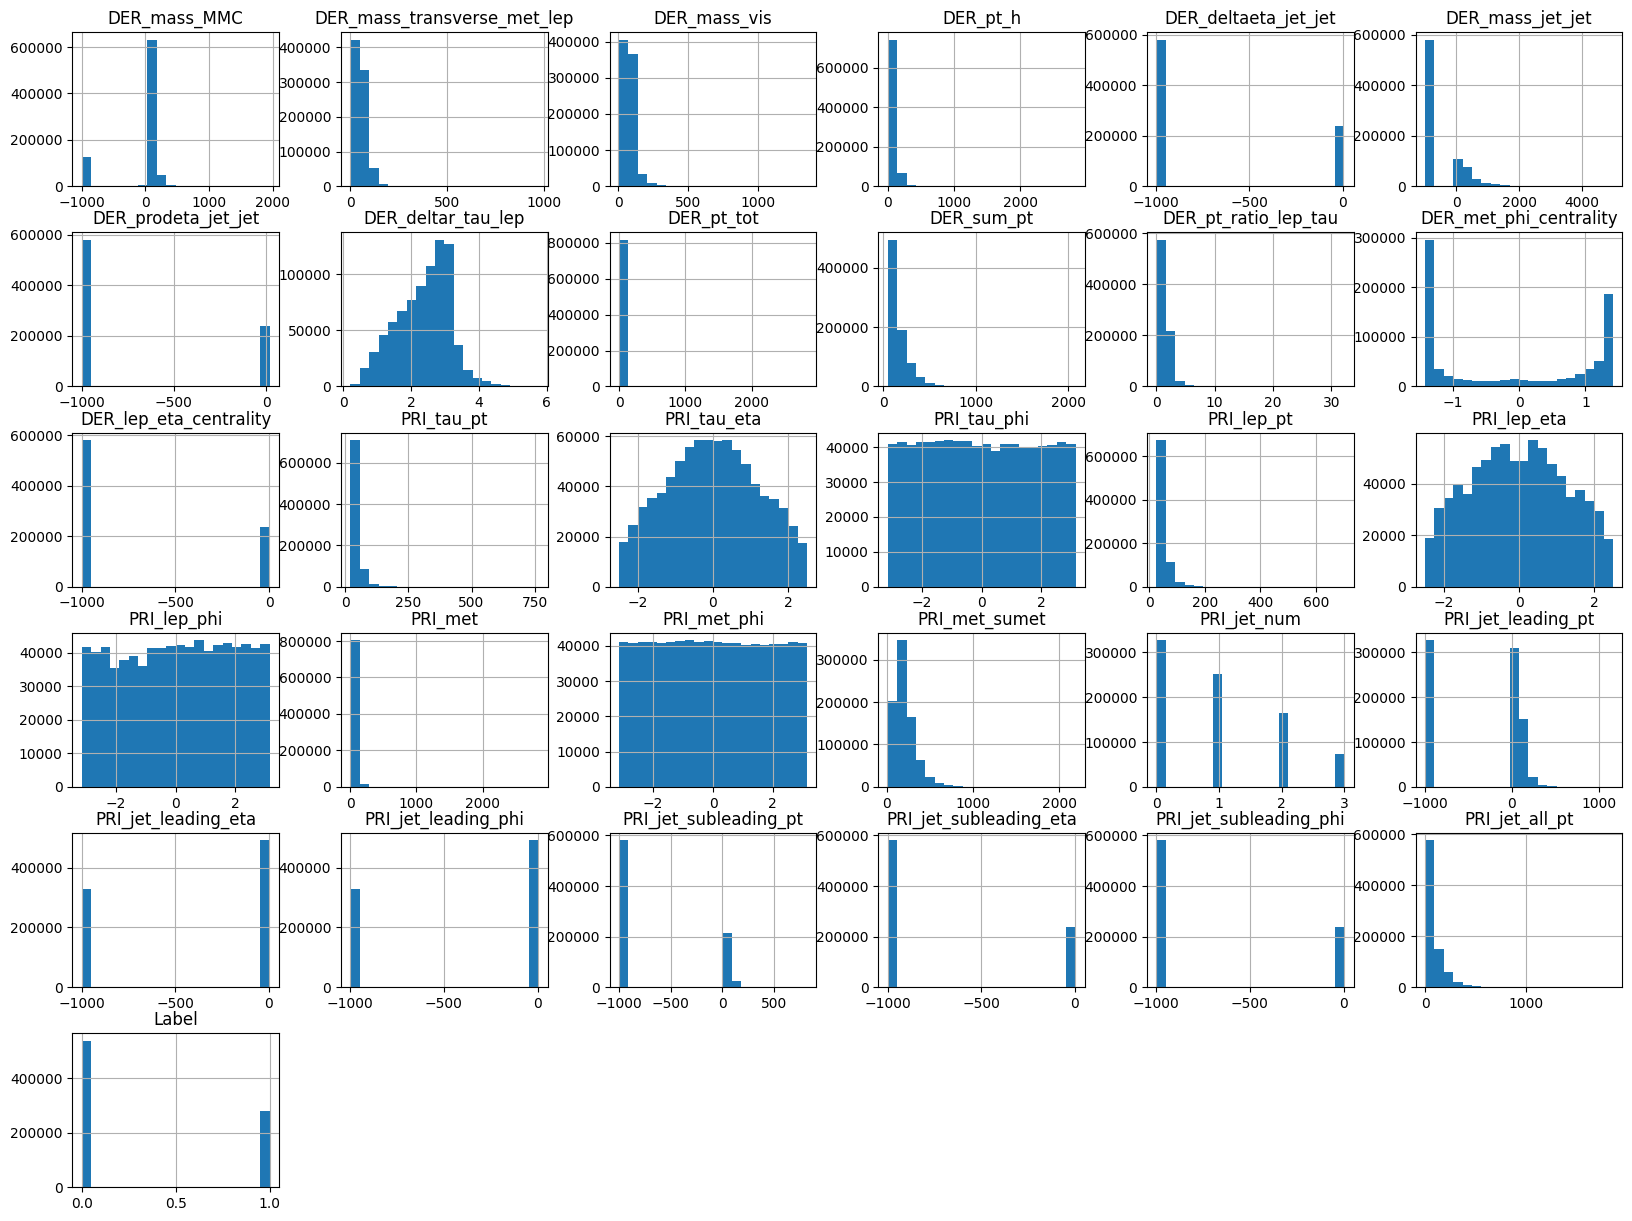

In [5]:
data.hist(bins = 20, figsize = (20,15))
plt.show()

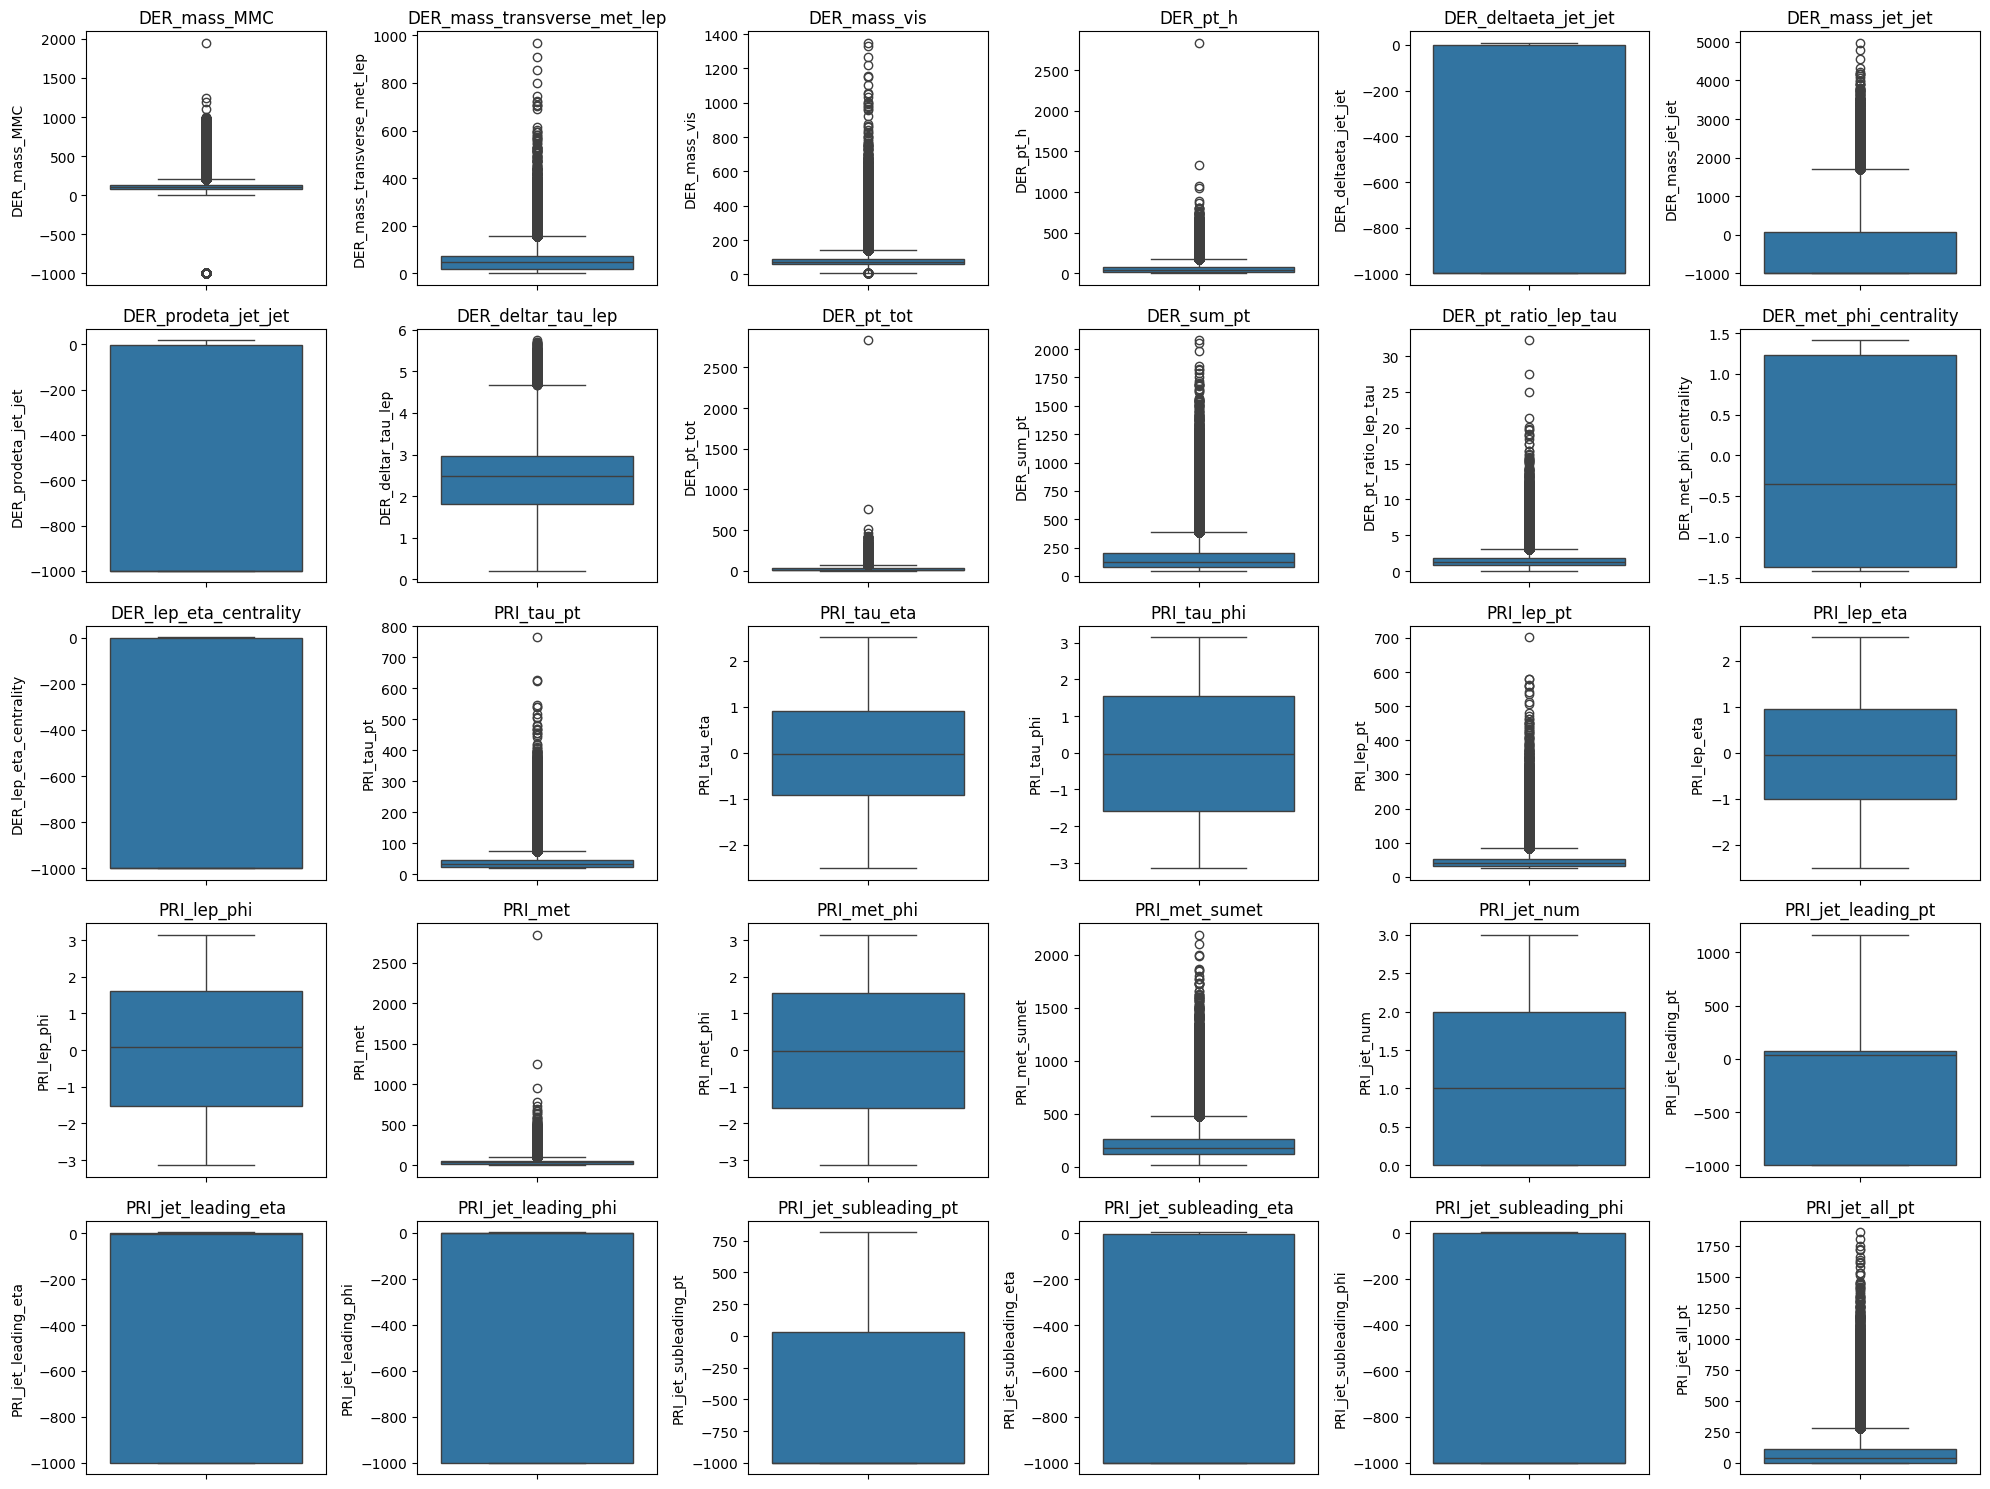

In [6]:
plt.figure(figsize=(20,15))
for i, column in enumerate(data.drop(columns=['Label']).columns):
    plt.subplot(5, 6, i + 1)
    sns.boxplot(y=data.drop(columns=['Label'])[column])
    plt.title(column)
plt.tight_layout()
plt.show()

### 5. Correlation

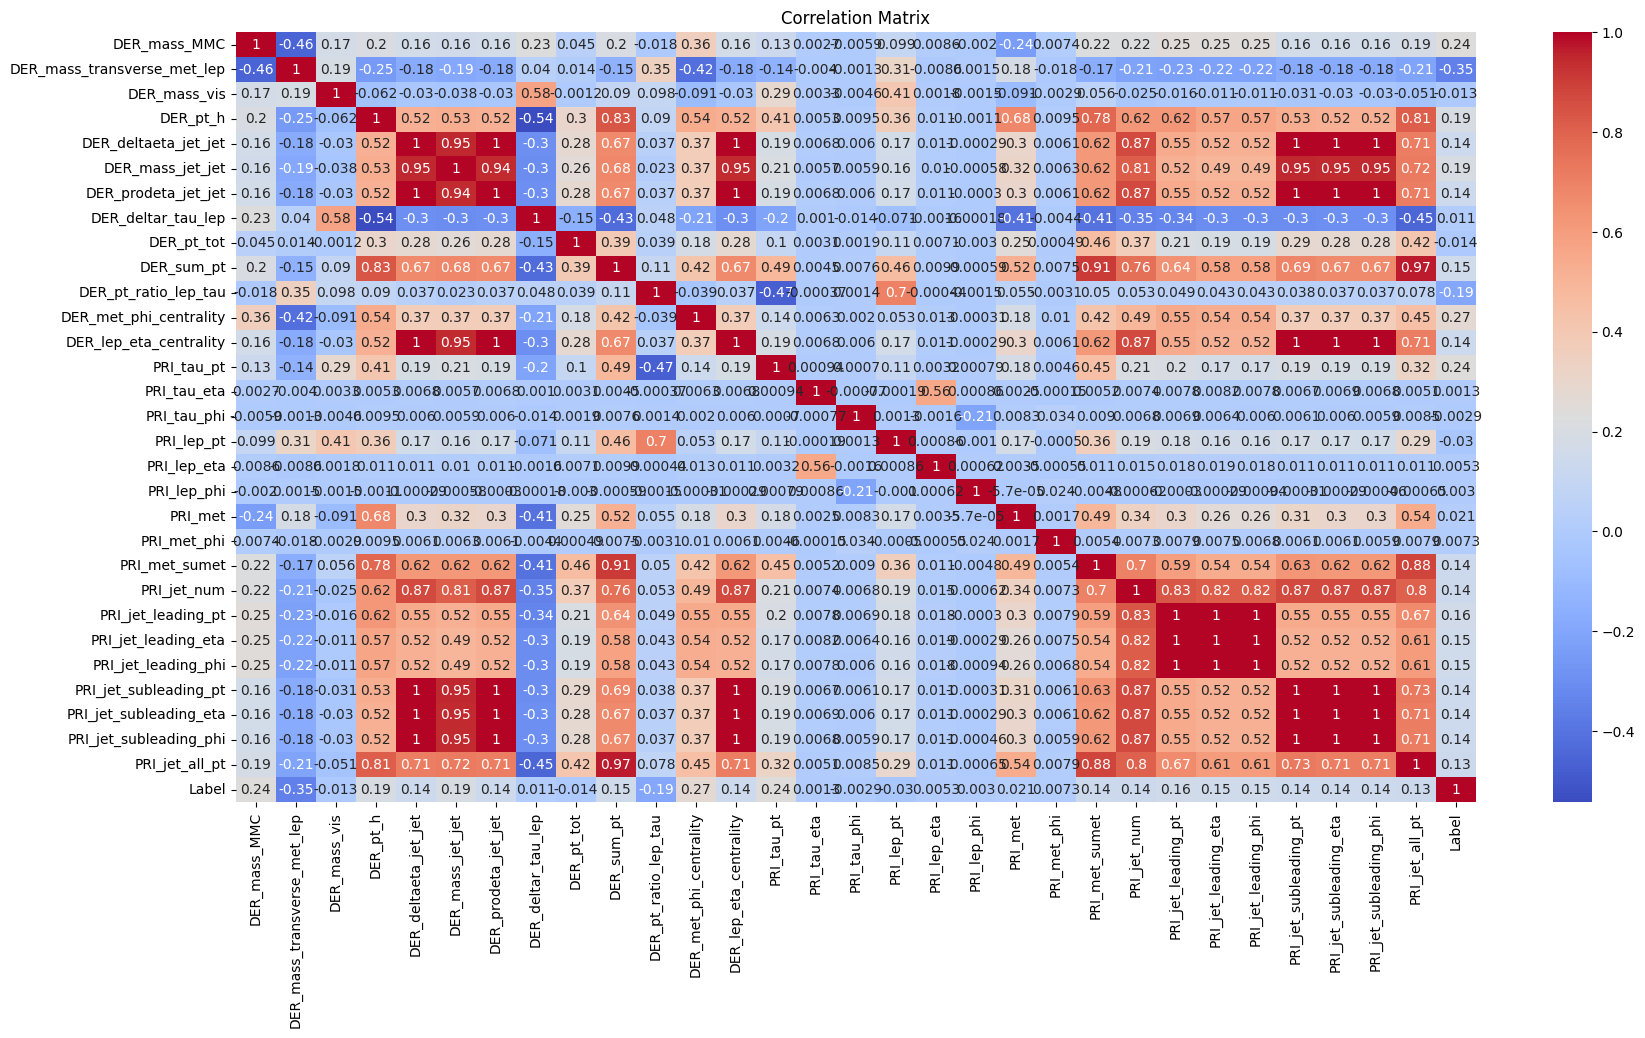

In [7]:
corr_mat=pd.DataFrame(data, columns=data.columns).corr()
plt.figure(figsize=(20,10))
sns.heatmap(corr_mat,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### 6. Check for missing values

In [8]:
print("--------- NULL VALUES (%) --------", data.isnull().sum() / data.shape[0] * 100, sep='\n')
print("\n------------ -999 VALUES (%) -----------", (data == -999.0).sum() / data.shape[0] * 100, sep='\n')

--------- NULL VALUES (%) --------
DER_mass_MMC                   0.0
DER_mass_transverse_met_lep    0.0
DER_mass_vis                   0.0
DER_pt_h                       0.0
DER_deltaeta_jet_jet           0.0
DER_mass_jet_jet               0.0
DER_prodeta_jet_jet            0.0
DER_deltar_tau_lep             0.0
DER_pt_tot                     0.0
DER_sum_pt                     0.0
DER_pt_ratio_lep_tau           0.0
DER_met_phi_centrality         0.0
DER_lep_eta_centrality         0.0
PRI_tau_pt                     0.0
PRI_tau_eta                    0.0
PRI_tau_phi                    0.0
PRI_lep_pt                     0.0
PRI_lep_eta                    0.0
PRI_lep_phi                    0.0
PRI_met                        0.0
PRI_met_phi                    0.0
PRI_met_sumet                  0.0
PRI_jet_num                    0.0
PRI_jet_leading_pt             0.0
PRI_jet_leading_eta            0.0
PRI_jet_leading_phi            0.0
PRI_jet_subleading_pt          0.0
PRI_jet_subleading_e

There is no null values in any column, however, in this dataset, missing values are designed by -999.0

I replace them using `SimpleImputer`

In [9]:
imputer = SimpleImputer(missing_values=-999, strategy='mean')
imputer.fit(data)
data = pd.DataFrame(imputer.transform(data), columns=data.columns)

### 7. Data scaling

In [10]:
X = data.drop(columns=['Label']).values
y = data['Label'].values

scaler = MinMaxScaler()
data_normalized = pd.DataFrame(scaler.fit_transform(X), columns=data.drop(columns = ["Label"]).columns)
data_normalized['Label'] = y

In [11]:
data.head()

,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,...,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Label
0,138.470000,51.655,97.827,27.980,0.910000,124.71100,2.66600,3.064,41.928,197.760,...,258.733,2.0,67.435000,2.150000,0.444000,46.062000,1.240000,-2.47500,113.497,1.0
1,160.937000,68.768,103.235,48.146,2.404626,372.18105,-0.82874,3.473,2.078,125.157,...,164.546,1.0,46.226000,0.725000,1.158000,57.810286,-0.006669,-0.01047,46.226,0.0
2,121.867697,162.172,125.953,35.635,2.404626,372.18105,-0.82874,3.148,9.336,197.814,...,260.414,1.0,44.251000,2.053000,-2.028000,57.810286,-0.006669,-0.01047,44.251,0.0
3,143.905000,81.417,80.943,0.414,2.404626,372.18105,-0.82874,3.310,0.414,75.968,...,86.062,0.0,84.904285,-0.001248,-0.018856,57.810286,-0.006669,-0.01047,-0.000,0.0
4,175.864000,16.915,134.805,16.405,2.404626,372.18105,-0.82874,3.891,16.405,57.983,...,53.131,0.0,84.904285,-0.001248,-0.018856,57.810286,-0.006669,-0.01047,0.000,0.0


In [12]:
data_normalized.head()

,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,...,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Label
0,0.066707,0.053326,0.068128,0.009869,0.104310,0.022395,0.591293,0.515244,0.014789,0.074595,...,0.112586,0.666667,0.033028,0.738889,0.570656,0.020388,0.637778,0.106143,0.061014,1.0
1,0.078287,0.070992,0.072155,0.016983,0.275633,0.072274,0.495970,0.589031,0.000733,0.038884,...,0.069314,0.333333,0.014316,0.580556,0.684278,0.035301,0.499259,0.498334,0.024850,0.0
2,0.058150,0.167417,0.089071,0.012570,0.275633,0.072274,0.495970,0.530399,0.003293,0.074622,...,0.113359,0.333333,0.012573,0.728111,0.177276,0.035301,0.499259,0.498334,0.023789,0.0
3,0.069508,0.084050,0.055557,0.000146,0.275633,0.072274,0.495970,0.559625,0.000146,0.014690,...,0.033256,0.000000,0.048440,0.499861,0.496999,0.035301,0.499259,0.498334,0.000000,0.0
4,0.085980,0.017462,0.095662,0.005787,0.275633,0.072274,0.495970,0.664442,0.005787,0.005843,...,0.018126,0.000000,0.048440,0.499861,0.496999,0.035301,0.499259,0.498334,0.000000,0.0


### 8. Split data

I separate the output to make some checks after (I do it before checking outlier because if I do it after, the outlier graph can plot 30 columns but we have 31 with the Label column)

In [13]:
X = data_normalized.drop('Label', axis=1)
y = data_normalized['Label']

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=42)

print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(572766, 30) (245472, 30) (572766,) (245472,)


### 9. Check unbalanced ratio

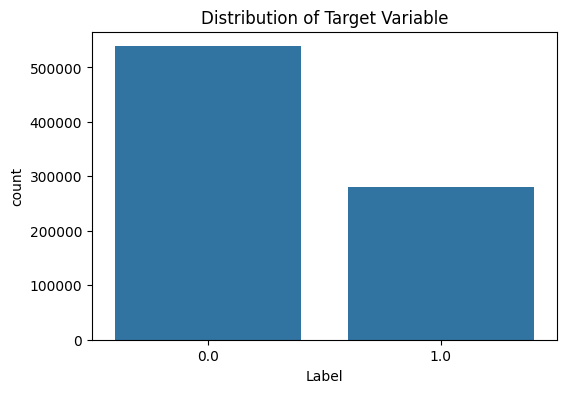

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='Label', data=data)
plt.title('Distribution of Target Variable')
plt.show()

We can see that the data is not really balanced so I balanced them using SMOTE and BSMOTE, to compare the technics at the end.

#### Balancing Data

In [15]:
# create a first copy of x_train
X_train_original = X_train.copy()

# Create a balanced set X_train2 using SMOTE
smote = SMOTE(random_state=42)
X_train_SMOTE, y_train2 = smote.fit_resample(X_train, y_train)

# Create an other balanced set X_train3 using Borderline SMOTE
Bsmote = BorderlineSMOTE(random_state=42)
X_train_BSMOTE, y_train3 = Bsmote.fit_resample(X_train, y_train)

### 10. Dimensionality reduction

In [16]:
pca = PCA(n_components=0.90)
pca.fit(X_train_original)

#Transforming learning data
X_train_copy = pca.transform(X_train_original)
X_test_copy = pca.transform(X_test)
print(X_train_copy.shape, X_test_copy.shape)

(572766, 10) (245472, 10)


### 11. Pipeline

In [17]:
preprocessing_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(missing_values=-999, strategy='mean')),
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=0.90))
])

preprocessing_pipeline.fit(X_train_original)

X_train_original = preprocessing_pipeline.transform(X_train_original)
X_test = preprocessing_pipeline.transform(X_test)
X_train_SMOTE = preprocessing_pipeline.transform(X_train_SMOTE)
X_train_BSMOTE = preprocessing_pipeline.transform(X_train_BSMOTE)

## II - Evolutionary Learning with DEAP

In [18]:
import random
import operator
import numpy as np
from deap import base, creator, tools, gp, algorithms
from sklearn.metrics import accuracy_score, f1_score

### 1. Set up DEAP components

In [19]:
n_features = X_train_original.shape[1]

# Create a Primitive Set. "MAIN" is the name, n_features is the number of inputs (ARG0, ARG1...)
pset = gp.PrimitiveSet("MAIN", n_features)

# Add arithmetic operators (Genetic Program nodes)
pset.addPrimitive(np.add, 2)
pset.addPrimitive(np.subtract, 2)
pset.addPrimitive(np.multiply, 2)
pset.addPrimitive(np.negative, 1)

# Add protected division to avoid division by zero errors
def protectedDiv(left, right):
    try:
        with np.errstate(divide='ignore', invalid='ignore'):
            x = np.divide(left, right)
            if isinstance(x, np.ndarray):
                x[np.isinf(x)] = 1
                x[np.isnan(x)] = 1
            elif np.isinf(x) or np.isnan(x):
                return 1
    except ZeroDivisionError:
        return 1
    return x

pset.addPrimitive(protectedDiv, 2)

# Add ephemeral constants (random numbers that can be part of the formula)
pset.addEphemeralConstant("rand101", lambda: random.randint(-1, 1))

# Rename arguments to x0, x1, etc. for better readability
pset.renameArguments(**{f"ARG{i}": f"x{i}" for i in range(n_features)})


# 1. Fitness Function: We want to Maximize Accuracy (weight = 1.0)
# If you wanted to maximize F1 score, you could use that too.
if hasattr(creator, "FitnessMax"): del creator.FitnessMax
creator.create("FitnessMax", base.Fitness, weights=(1.0,))

# 2. Individual: A Tree structure
if hasattr(creator, "Individual"): del creator.Individual
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMax)

# 3. Toolbox
toolbox = base.Toolbox()
toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=1, max_=2) # Tree generation strategy
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("compile", gp.compile, pset=pset)

c:\Users\auria\AppData\Local\Programs\Python\Python312\Lib\site-packages\deap\gp.py:257: RuntimeWarning: Ephemeral rand101 function cannot be pickled because its generating function is a lambda function. Use functools.partial instead.
  warnings.warn("Ephemeral {name} function cannot be "


### 2. Evaluation function

In [20]:
def evalSymbReg(individual, X, y):
    # Compile the tree expression into a callable function
    func = toolbox.compile(expr=individual)
    
    # Apply the function to the input data
    # We transpose X (.T) because the function expects arguments x0, x1... 
    # and numpy can broadcast these operations if inputs are arrays.
    try:
        result = func(*X.T) 
    except Exception:
        # If the generated formula is invalid (e.g. overflow), give bad fitness
        return 0,

    # Convert continuous output to class labels (0 or 1)
    # Sigmoid-like logic: if result > 0 predict 1 (Signal), else 0 (Background)
    # Ensure result is a numpy array
    if isinstance(result, np.ndarray):
        predictions = (result > 0).astype(int)
    else:
        # If result is a single scalar (rare but possible with constant trees), broadcast it
        predictions = np.full(y.shape, int(result > 0))
        
    return accuracy_score(y, predictions),

# Register the evaluation function
# Note: Use your actual training variable names here (e.g., X_train_SMOTE, y_train_SMOTE)
# For speed, you might want to slice them: evaluate(individual, X_train_SMOTE[:5000], y_train_SMOTE[:5000])
toolbox.register("evaluate", evalSymbReg, X=X_train_SMOTE, y=y_train)

### 3. Genetic Operators

In [21]:
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("expr_mut", gp.genFull, min_=0, max_=2)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)

# Decorators to limit tree height (prevents bloat)
toolbox.decorate("mate", gp.staticLimit(key=operator.attrgetter("height"), max_value=17))
toolbox.decorate("mutate", gp.staticLimit(key=operator.attrgetter("height"), max_value=17))

### Run

In [22]:
def main():
    random.seed(42)
    
    # Population size (e.g., 50 or 100 for speed, 300 for better results)
    pop = toolbox.population(n=50) 
    hof = tools.HallOfFame(1) # Store the best individual
    
    # Statistics to track progress
    stats_fit = tools.Statistics(lambda ind: ind.fitness.values)
    stats_size = tools.Statistics(len)
    mstats = tools.MultiStatistics(fitness=stats_fit, size=stats_size)
    mstats.register("avg", np.mean)
    mstats.register("std", np.std)
    mstats.register("min", np.min)
    mstats.register("max", np.max)
    
    # Run the algorithm
    # cxpb = crossover probability, mutpb = mutation probability, ngen = generations
    pop, log = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.1, ngen=10, 
                                   stats=mstats, halloffame=hof, verbose=True)
    
    return pop, log, hof

# Run it
pop, log, hof = main()

ValueError: Found input variables with inconsistent numbers of samples: [572766, 754326]

### Test best model

In [ ]:
# Get the best individual
best_ind = hof[0]
print("Best Individual:", best_ind)
print("Best Training Accuracy:", best_ind.fitness.values[0])

# Compile and predict on Test Set
best_func = toolbox.compile(expr=best_ind)

# Predict on test data
try:
    test_result = best_func(*X_test.T)
    if isinstance(test_result, np.ndarray):
        y_pred = (test_result > 0).astype(int)
    else:
        y_pred = np.full(y_test.shape, int(test_result > 0))
        
    # Calculate metrics
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Test F1 Score: {f1_score(y_test, y_pred):.4f}")
    
except Exception as e:
    print("Error applying best function to test set:", e)